In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [16]:
# -------------------------------
# STEP 1: Load Dataset
# -------------------------------
df = pd.read_csv("academic_small_10.csv")

print("=== Dataset Preview ===")
print(df.head())

print("\n=== Missing Values ===")
print(df.isnull().sum())


=== Dataset Preview ===
  Name  Math  Science  English  Attendance
0    A  78.0     88.0     72.0          85
1    B  85.0     92.0     80.0          90
2    C   NaN     85.0     78.0          88
3    D  90.0      NaN     85.0          92
4    E  65.0     70.0      NaN          70

=== Missing Values ===
Name          0
Math          2
Science       2
English       1
Attendance    0
dtype: int64


In [23]:


# -------------------------------
# STEP 2: Handle Missing Values
# -------------------------------
df["Math"] = df["Math"].fillna(df["Math"].mean())
df["Science"] = df["Science"].fillna(df["Science"].mean())
df["English"] = df["English"].fillna(df["English"].mean())

print("\n=== After Handling Missing Values ===")
print(df.isnull().sum())



# -------------------------------
# STEP 3: Fix Inconsistencies
# -------------------------------
df["Math"] = np.where(df["Math"] > 100, 100, df["Math"])
df["Science"] = np.where(df["Science"] > 100, 100, df["Science"])
df["English"] = np.where(df["English"] > 100, 100, df["English"])
df["Attendance"] = np.where(df["Attendance"] > 100, 100, df["Attendance"])






=== After Handling Missing Values ===
Name          0
Math          0
Science       0
English       0
Attendance    0
dtype: int64


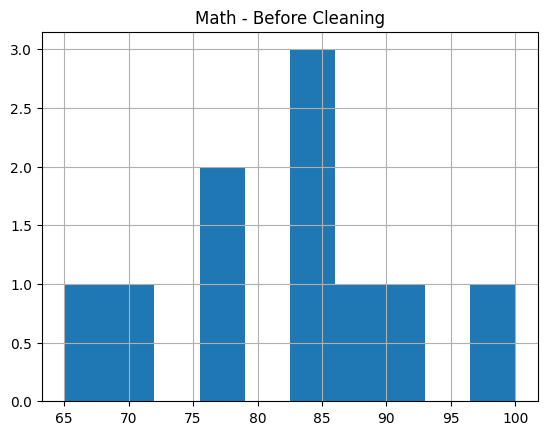

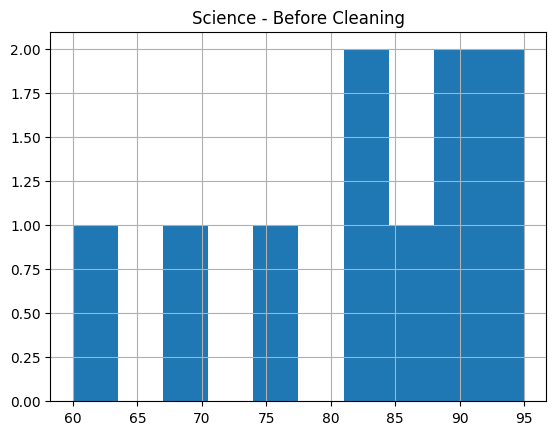

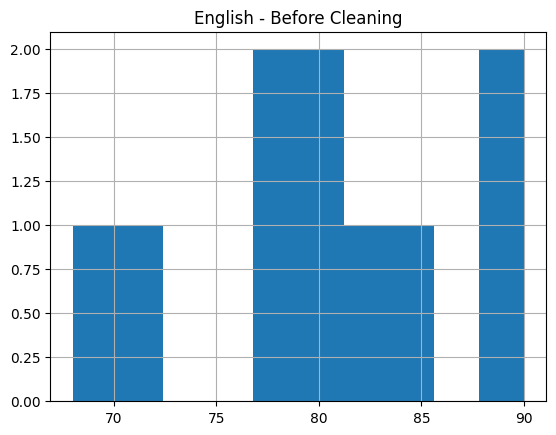

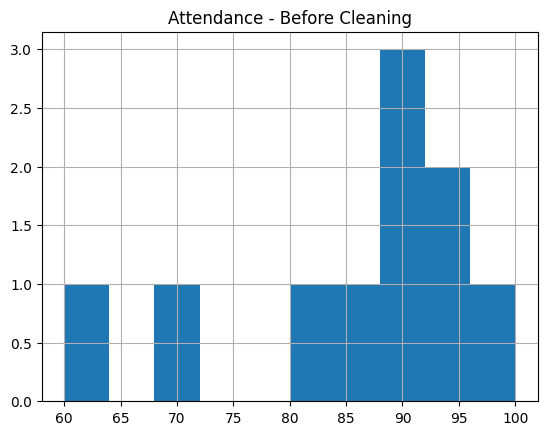

In [24]:
# -------------------------------
# STEP 4: Histograms (Before Cleaning)
# -------------------------------
df["Math"].hist()
plt.title("Math - Before Cleaning")
plt.show()

df["Science"].hist()
plt.title("Science - Before Cleaning")
plt.show()

df["English"].hist()
plt.title("English - Before Cleaning")
plt.show()

df["Attendance"].hist()
plt.title("Attendance - Before Cleaning")
plt.show()

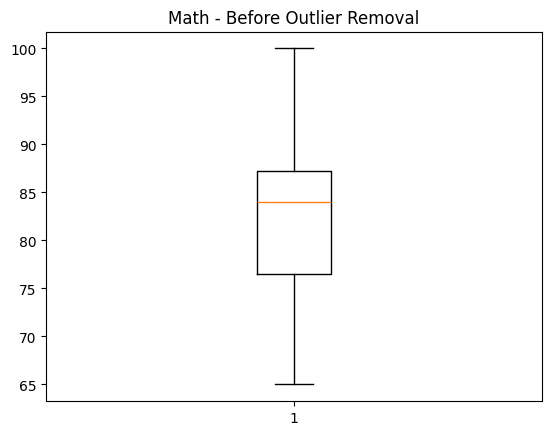

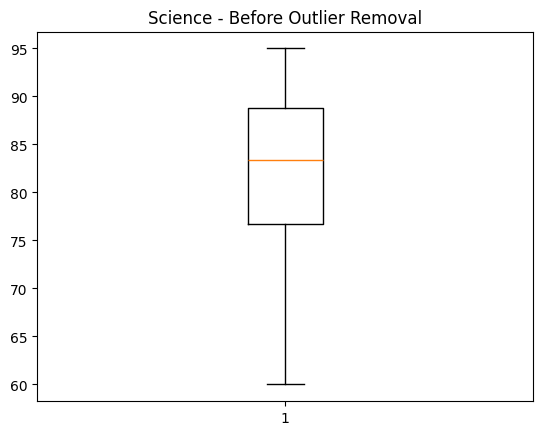

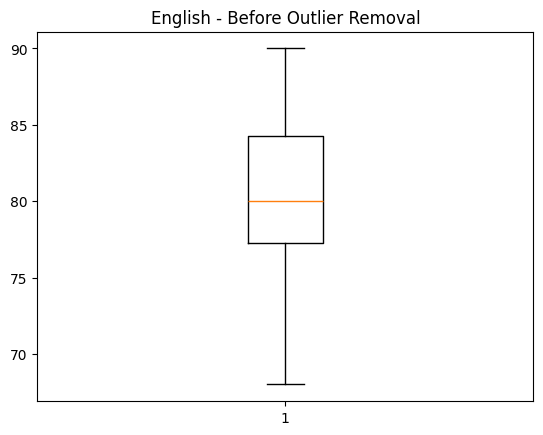

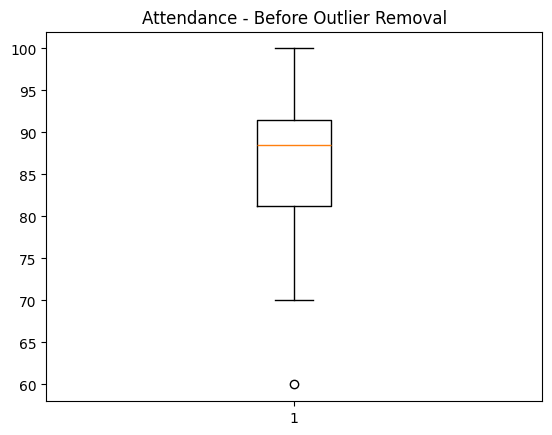

In [25]:
# -------------------------------
# STEP 5: Boxplots (Before Cleaning)
# -------------------------------
plt.boxplot(df["Math"])
plt.title("Math - Before Outlier Removal")
plt.show()

plt.boxplot(df["Science"])
plt.title("Science - Before Outlier Removal")
plt.show()

plt.boxplot(df["English"])
plt.title("English - Before Outlier Removal")
plt.show()

plt.boxplot(df["Attendance"])
plt.title("Attendance - Before Outlier Removal")
plt.show()


In [27]:
# -------------------------------
# STEP 6: Outlier Detection (IQR)
# -------------------------------
Q1 = df["Math"].quantile(0.25)
Q3 = df["Math"].quantile(0.75)
IQR = Q3 - Q1
lower_math = Q1 - 1.5 * IQR
upper_math = Q3 + 1.5 * IQR

Q1 = df["Science"].quantile(0.25)
Q3 = df["Science"].quantile(0.75)
IQR = Q3 - Q1
lower_science = Q1 - 1.5 * IQR
upper_science = Q3 + 1.5 * IQR

Q1 = df["English"].quantile(0.25)
Q3 = df["English"].quantile(0.75)
IQR = Q3 - Q1
lower_english = Q1 - 1.5 * IQR
upper_english = Q3 + 1.5 * IQR

Q1 = df["Attendance"].quantile(0.25)
Q3 = df["Attendance"].quantile(0.75)
IQR = Q3 - Q1
lower_att = Q1 - 1.5 * IQR
upper_att = Q3 + 1.5 * IQR

In [30]:
# -------------------------------
# STEP 7: Handle Outliers (Capping)
# -------------------------------
df["Math"] = np.where(df["Math"] > upper_math, upper_math, df["Math"])
df["Math"] = np.where(df["Math"] < lower_math, lower_math, df["Math"])

df["Science"] = np.where(df["Science"] > upper_science, upper_science, df["Science"])
df["Science"] = np.where(df["Science"] < lower_science, lower_science, df["Science"])

df["English"] = np.where(df["English"] > upper_english, upper_english, df["English"])
df["English"] = np.where(df["English"] < lower_english, lower_english, df["English"])

df["Attendance"] = np.where(df["Attendance"] > upper_att, upper_att, df["Attendance"])
df["Attendance"] = np.where(df["Attendance"] < lower_att, lower_att, df["Attendance"])

print("\n=== After Outlier Handling ===")
print(df.describe())



=== After Outlier Handling ===
             Math    Science   English  Attendance
count   10.000000  10.000000  10.00000   10.000000
mean    82.000000  81.750000  80.00000   85.487500
std     10.143416  10.747093   6.78233   10.736175
min     65.000000  60.000000  68.00000   65.875000
25%     76.500000  76.687500  77.25000   81.250000
50%     84.000000  83.375000  80.00000   88.500000
75%     87.250000  88.750000  84.25000   91.500000
max    100.000000  95.000000  90.00000  100.000000


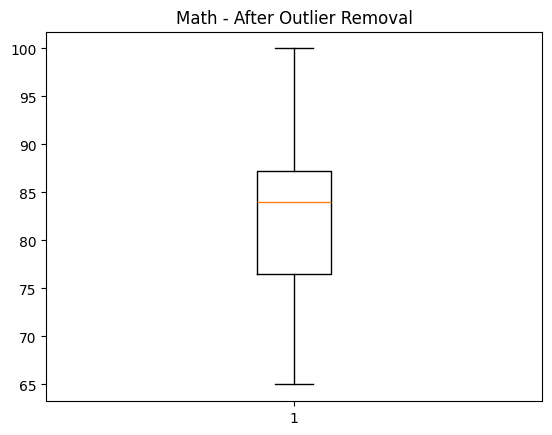

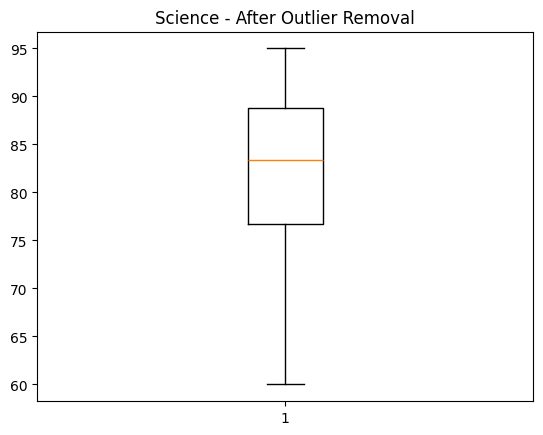

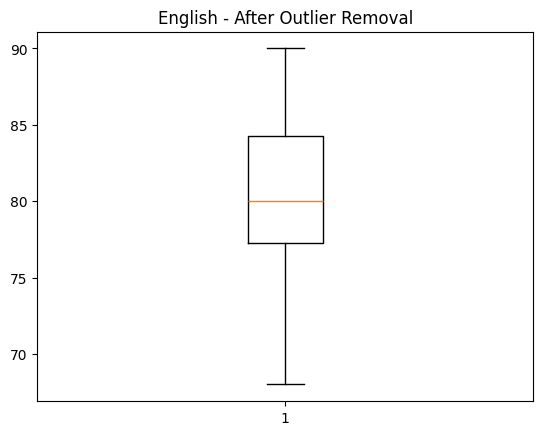

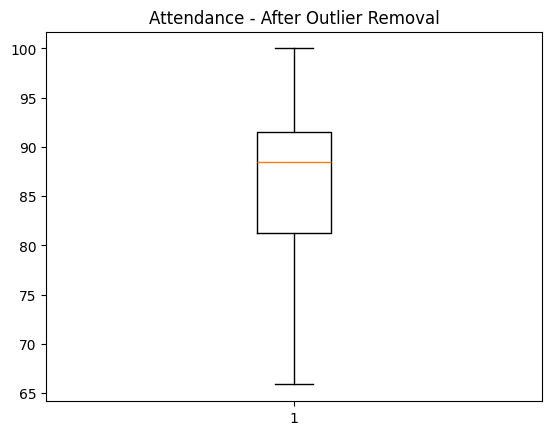

In [31]:
# -------------------------------
# STEP 8: Boxplots (After Cleaning)
# -------------------------------
plt.boxplot(df["Math"])
plt.title("Math - After Outlier Removal")
plt.show()

plt.boxplot(df["Science"])
plt.title("Science - After Outlier Removal")
plt.show()

plt.boxplot(df["English"])
plt.title("English - After Outlier Removal")
plt.show()

plt.boxplot(df["Attendance"])
plt.title("Attendance - After Outlier Removal")
plt.show()

In [32]:
# -------------------------------
# STEP 9: Normalization
# -------------------------------
df["Math"] = (df["Math"] - df["Math"].min()) / (df["Math"].max() - df["Math"].min())
df["Science"] = (df["Science"] - df["Science"].min()) / (df["Science"].max() - df["Science"].min())
df["English"] = (df["English"] - df["English"].min()) / (df["English"].max() - df["English"].min())
df["Attendance"] = (df["Attendance"] - df["Attendance"].min()) / (df["Attendance"].max() - df["Attendance"].min())

print("\n=== After Normalization ===")
print(df.head())


=== After Normalization ===
  Name      Math   Science   English  Attendance
0    A  0.371429  0.800000  0.181818    0.560440
1    B  0.571429  0.914286  0.545455    0.706960
2    C  0.542857  0.714286  0.454545    0.648352
3    D  0.714286  0.621429  0.772727    0.765568
4    E  0.000000  0.285714  0.545455    0.120879


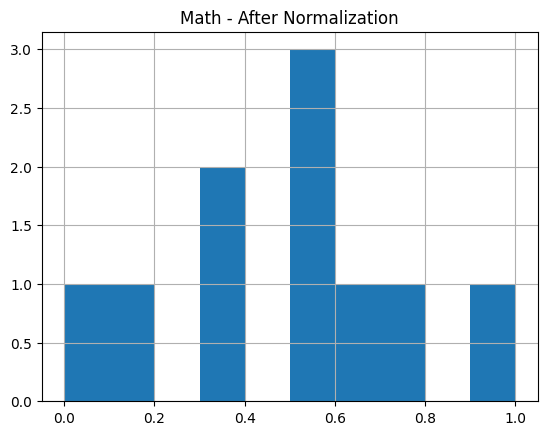

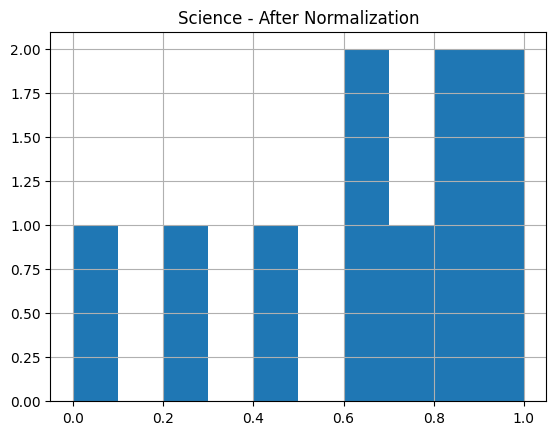

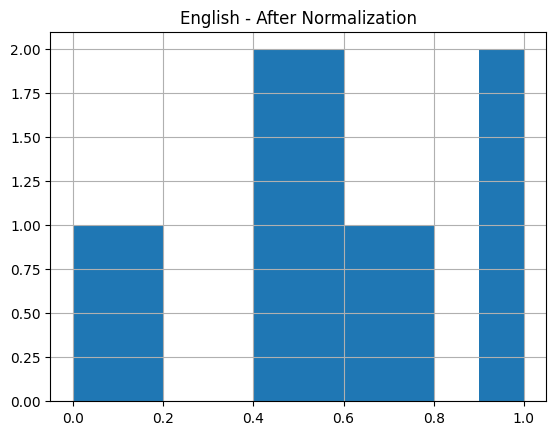

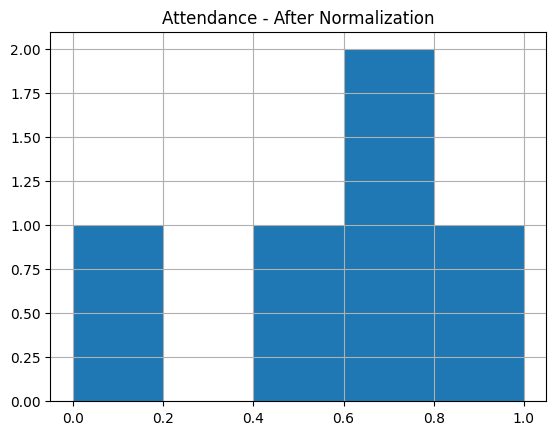

In [33]:
# -------------------------------
# STEP 10: Histogram After Transformation
# -------------------------------
df["Math"].hist()
plt.title("Math - After Normalization")
plt.show()

df["Science"].hist()
plt.title("Science - After Normalization")
plt.show()

df["English"].hist()
plt.title("English - After Normalization")
plt.show()

df["Attendance"].hist()
plt.title("Attendance - After Normalization")
plt.show()